In [1]:
"""Tool to plot infer some analysis on TPO"""
from dataclasses import dataclass, field
from os import listdir
import matplotlib.pyplot as plt
from pandas import DataFrame, read_csv, concat
from sklearn.linear_model import LinearRegression
# 
import numpy as np
from scipy import sparse
from scipy.sparse.linalg import spsolve

In [11]:
# Global variables
SHOW_PLOTS = True
TEST_OUT = False


@dataclass
class Measurment:
    """Class to represent a measurment"""
    filename: str
    data: DataFrame = field(init=False)
    integral: list = field(init=False)
    def __post_init__(self):
        self.data = read_csv(self.filename, sep=';', header=0)
        # drop first column
        self.data = self.data.drop(self.data.columns[0], axis=1)
        #substitute comma with dot
        self.data = self.data.apply(lambda x: x.str.replace(',','.'))
        #convert to float
        self.data = self.data.astype(float)
        self.data.columns = [ 'Displacement', self.filename]
        # round the displacement
        self.data['Displacement'] = self.data['Displacement'].apply(lambda x: round(x, 1))
        
        self.integral = np.trapz(self.data[self.filename], self.data['Displacement'])
        


    def clean(self, **kwargs):
        """Remove all rows with NaN"""
        self.data = self.data.astype(float)
        #self.data = self.data[self.data["Displacement"] > 0]
        #self.data = self.data[self.data["Displacement"] < 85]    
        self.data = self.data.dropna()
        self.data = self.data.groupby(by='Displacement').mean()
        self.data = shift(self.data,  **kwargs)
        self.data = smooth(self.data, **kwargs)

    def plot(self, **kwargs):
        """Plot the data"""
        plt.plot(self.data, label=self.filename, **kwargs)

def shift(df, **kwargs):
    """Shift the data to the right"""
    N = df.where(df > 1).first_valid_index()
    index = np.array(df.index)
    index = index + 30 - N
    df.index = index

    return df

def smooth(df, **kwargs):
    ## take the min in index and max in index
    min_index = df.index.min()
    max_index = df.index.max()
    ## create a new index
    new_index = np.arange(round(min_index, 1), round(max_index, 1), 0.1)
    ## create a new dataframe
    new_df = DataFrame(index=new_index)
    ## interpolate the data
    new_df = new_df.interpolate(method='linear', axis=0)
    ## merge the dataframes
    new_df = new_df.merge(df, left_index=True, right_index=True, how='outer')
    # interpolate the data
    new_df = new_df.interpolate(method='linear', axis=0)
    return new_df

def MaxPoint(df, start_index, end_index):
    """Max point of a dataframe in an interval of the indices"""
    max_value = df[start_index:end_index].max()
    max_index = df[start_index:end_index].idxmax()
    return max_value, max_index

    


   




def PlotterSingle(namedir, N, **kwargs):

    measurments = []
    exp = DataFrame()
    plt.figure(figsize=(10, 5))
    for filename in listdir(namedir):
        measurments.append(Measurment(namedir+"/"+filename))
        measurments[-1].clean(**kwargs)
    
    t_min = max([i.data.index.min() for i in measurments])
    t_max = min([i.data.index.max() for i in measurments])
    exp = DataFrame(index=np.arange(round(t_min, 1), round(t_max,1), 0.1))
    for m in measurments:
        exp= concat([exp, m.data], axis=1)
        
    exp = smooth(exp)

    if TEST_OUT:
        exp.plot( )

    mean = exp.mean(axis=1).dropna()
    integral = np.trapz(mean, mean.index)
    print("integral", integral)
    

    # add 1 to the values
    
    print(exp)
    if False:
        mean.plot(color="black", legend=False, linewidth=1.5, figsize=(10, 5), label = "mean")
        #display(mean)
        plt.grid()
        std = exp.std(axis=1).dropna() 
        plt.fill_between(mean.index, mean-std, mean+std, color="C0", alpha=0.5, label = "std")
        plt.xlabel("Displacement [mm]")
        plt.ylabel("Force [N]")
        title = "TPA oleogel RBX/RSO "+str(N)+"% "
        plt.title(title)
        plt.tight_layout()
        plt.plot(MaxPoint(mean, 0, 35,)[1],  MaxPoint(mean, 0, 35,)[0], 'o', color="C1", label = r"F0 : {:.2f} $\pm$ {}".format(MaxPoint(mean, 0, 35,)[0], round(std[MaxPoint(mean, 0, 35,)[1]], 2)))
        # same for [35 : 50]
        plt.plot(MaxPoint(mean, 35, 50,)[1],  MaxPoint(mean, 35, 50,)[0], 'o', color="C3", label = r"F1 : {:.2f} $\pm$ {}".format(MaxPoint(mean, 35, 50,)[0], round(std[MaxPoint(mean, 35, 50,)[1]], 2)))
#   
        plt.legend(loc="upper left")
        #if kwargs.get("save_plots", True):
        plt.savefig(title.replace("/", "").replace("%", "") +".png", dpi=1000)

    # save the data as a csv file
    #exp.to_csv(str(N)+"test.csv", sep=';')

def PlotterMultiple(namedir, displacement,  **kwargs):
    
    #plot subplots
    pass

    #plt.figure(figsize=(10, 5))
    #for N in [2, 4, 6, 8]:
    #    namedir = str(N)+"perc/csv"
    #    plt.subplot(2, 2, N/2)
    #    PlotterSingle(namedir, N, **kwargs)

    

In [12]:
p = 0.9
lam = 10**12
niter = 10
kwargs = {"p": p, "lam": lam, "niter": niter}

SHOW_PLOTS = False
TEST_OUT = False

integral 14.779181650369521


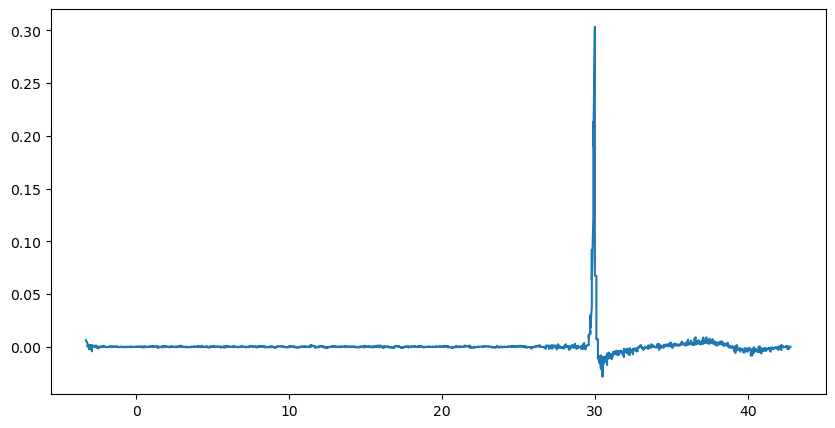

In [13]:
N = 2
namedir = str(N)+"perc/csv"
PlotterSingle(namedir, N, **kwargs)



integral 84.00987336513349


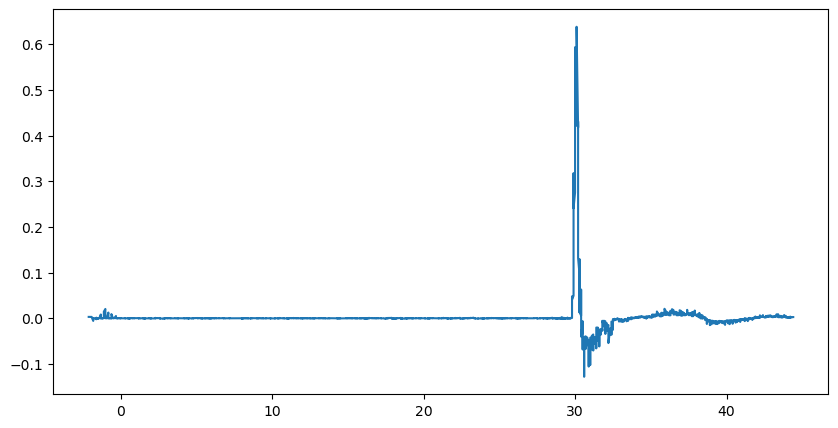

In [5]:
N = 4
namedir = str(N)+"perc/csv"

PlotterSingle(namedir, N, **kwargs)



integral 103.05371840939232


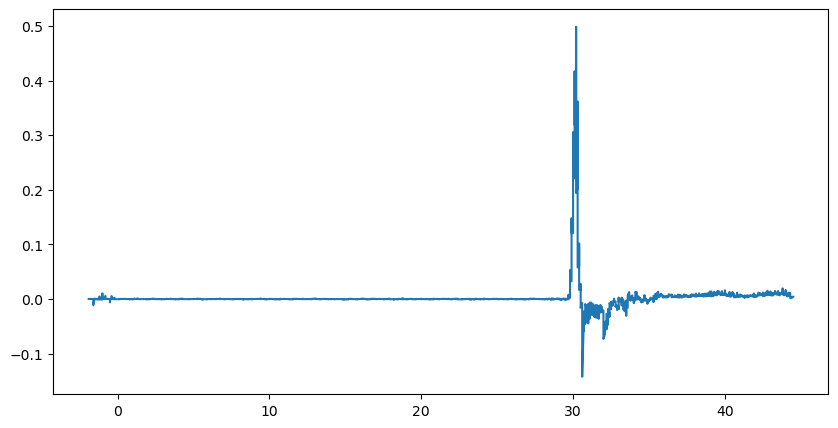

In [6]:
N = 6
namedir = str(N)+"perc/csv"

PlotterSingle(namedir, N, **kwargs)


integral 133.65169873377343


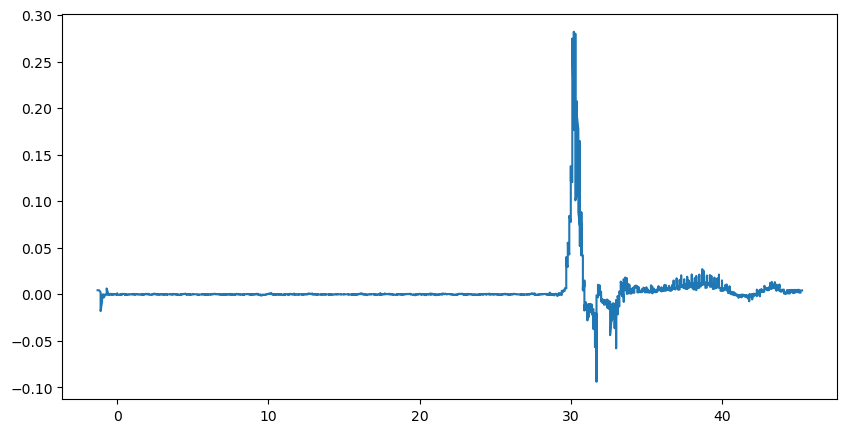

In [7]:
N = 8
namedir = str(N)+"perc/csv"

PlotterSingle(namedir, N, **kwargs)


# Together

In [8]:
displacement = 1

PlotterMultiple(namedir, displacement, **kwargs)
